## UTILIDADES

In [ ]:
import numpy as np
import pandas as pd
import holidays

def add_cyclic_features(df):
  df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
  df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
  df['Day_sin'] = np.sin(2 * np.pi * df['Day'] / 31)
  df['Day_cos'] = np.cos(2 * np.pi * df['Day'] / 31)
  return df

def add_holiday_feature(df):
  uk_holidays = holidays.UK(years=range(2000, 2030))
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
  df['IsHoliday'] = df['InvoiceDate'].apply(lambda x: 1 if x.date() in uk_holidays else 0)
  return df

def add_lags(df, lags=[1, 7, 30]):
  for lag in lags:
      df[f'TotalSales_Lag{lag}'] = df['TotalSales'].shift(lag)
  return df

def add_rolling_means(df, windows=[7, 30]):
    for window in windows:
        df[f'TotalSales_Rolling{window}'] = df['TotalSales'].rolling(window).mean()
    return df

## Primera versión

In [ ]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd

df_to_train = pd.read_csv("../../data/dataset_training.csv")

X_to_train =  df_to_train[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']]
Y_to_train = df_to_train['TotalSales']

model =  XGBRegressor(
  n_estimators=100,
  max_depth=5,
  learning_rate=0.1,
  min_child_weight=10,
  subsample=0.8,
  colsample_bytree=0.8,
  random_state=42
)
model.fit(X_to_train, Y_to_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

RMSE: 12028.46
MAE: 10266.06


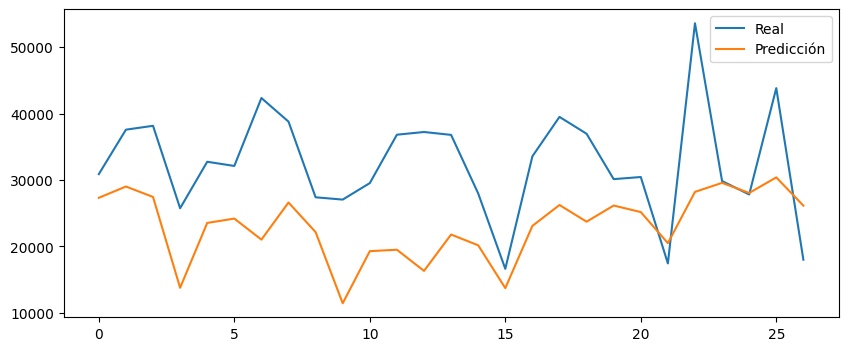

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_to_test = pd.read_csv("../../data/dataset_prediction.csv")
X_to_test = df_to_test[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']]
Y_to_test = df_to_test['TotalSales']

predictions = model.predict(X_to_test)

rmse = np.sqrt(mean_squared_error(Y_to_test, predictions))
mae = mean_absolute_error(Y_to_test, predictions)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Gráfico de comparación
plt.figure(figsize=(10, 4))
plt.plot(Y_to_test.values, label='Real')
plt.plot(predictions, label='Predicción')
plt.legend()
plt.show()

## Segunda versión

In [21]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd

df_to_train = pd.read_csv("../../data/dataset_training.csv")

X_to_train =  df_to_train[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']]
Y_to_train = df_to_train['TotalSales']

model =  XGBRegressor(
  n_estimators=300,
  max_depth=5,
  learning_rate=0.01,
  min_child_weight=10,
  subsample=0.8,
  colsample_bytree=1,
  random_state=42
)
model.fit(X_to_train, Y_to_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, random_state=42, ...)

RMSE: 10938.87
MAE: 9168.86


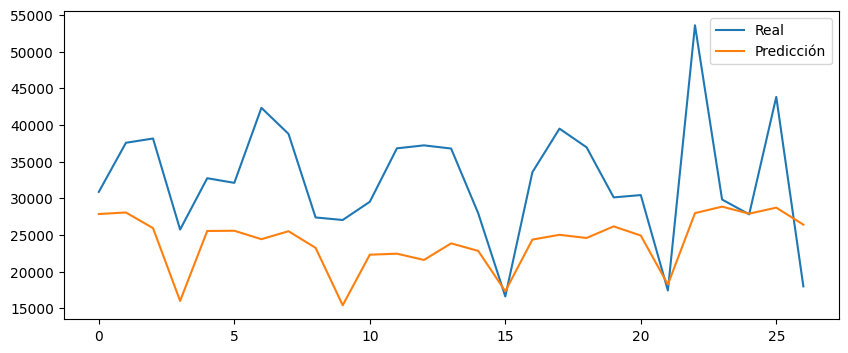

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_to_test = pd.read_csv("../../data/dataset_prediction.csv")
X_to_test = df_to_test[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']]
Y_to_test = df_to_test['TotalSales']

predictions = model.predict(X_to_test)

rmse = np.sqrt(mean_squared_error(Y_to_test, predictions))
mae = mean_absolute_error(Y_to_test, predictions)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Gráfico de comparación
plt.figure(figsize=(10, 4))
plt.plot(Y_to_test.values, label='Real')
plt.plot(predictions, label='Predicción')
plt.legend()
plt.show()

## Tercera versión

In [ ]:
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd

df_to_train = pd.read_csv("../../data/dataset_training.csv")
df_to_train = add_cyclic_features(df_to_train)
df_to_train = add_holiday_feature(df_to_train)
df_to_train = add_lags(df_to_train)
df_to_train = add_rolling_means(df_to_train)

df_to_train['IsMonthEnd'] = df_to_train['InvoiceDate'].dt.is_month_end.astype(int)
df_to_train['IsWeekend'] = (df_to_train['DayOfWeek'] >= 5).astype(int)

X_to_train =  df_to_train[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsHoliday', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']]
Y_to_train = df_to_train['TotalSales']

model =  XGBRegressor(
  n_estimators=300,
  max_depth=5,
  learning_rate=0.01,
  min_child_weight=10,
  subsample=0.8,
  colsample_bytree=1,
  random_state=42
)
model.fit(X_to_train, Y_to_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, random_state=42, ...)

RMSE: 11119.23
MAE: 9393.17


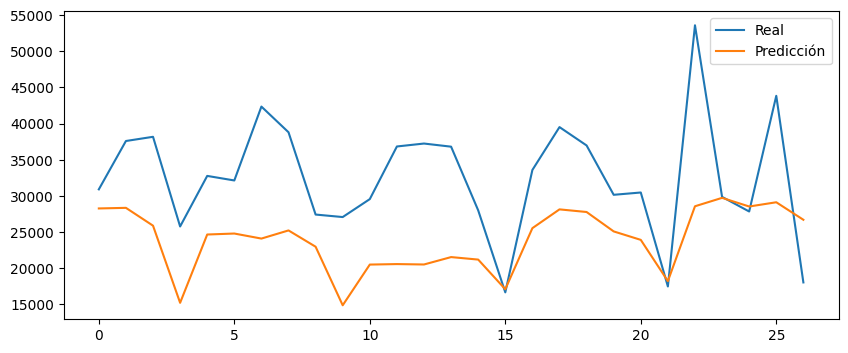

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_to_test = pd.read_csv("../../data/dataset_prediction.csv")
df_to_test = add_cyclic_features(df_to_test)
df_to_test = add_holiday_feature(df_to_test)
df_to_test = add_lags(df_to_test)
df_to_test = add_rolling_means(df_to_test)

df_to_test['IsMonthEnd'] = df_to_test['InvoiceDate'].dt.is_month_end.astype(int)
df_to_test['IsWeekend'] = (df_to_test['DayOfWeek'] >= 5).astype(int)

X_to_test =  df_to_test[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsHoliday', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']]
Y_to_test = df_to_test['TotalSales']

predictions = model.predict(X_to_test)

rmse = np.sqrt(mean_squared_error(Y_to_test, predictions))
mae = mean_absolute_error(Y_to_test, predictions)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

# Gráfico de comparación
plt.figure(figsize=(10, 4))
plt.plot(Y_to_test.values, label='Real')
plt.plot(predictions, label='Predicción')
plt.legend()
plt.show()

## Buscando los mejores parámetros

In [ ]:
from xgboost import XGBRegressor
import pandas as pd
from sklearn.model_selection import GridSearchCV

df_to_train = pd.read_csv("../../data/dataset_training.csv")

X_to_train = df_to_train[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter']]
Y_to_train = df_to_train['TotalSales']

param_grid = {
  'n_estimators': [100, 300, 500],
  'max_depth': [5, 10, 15],
  'learning_rate': [0.01, 0.1, 0.2],
  'min_child_weight': [1, 5, 10],
  'subsample': [0.8, 1],
  'colsample_bytree': [0.8, 1],
}

grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, scoring='neg_mean_squared_error', cv=5)
grid_search.fit(X_to_train, Y_to_train)

print(grid_search.best_params_)

# {'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 10, 'n_estimators': 300, 'subsample': 0.8}

{'colsample_bytree': 1, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 10, 'n_estimators': 300, 'subsample': 0.8}


# Mirando análisis de importancia de las variables

<Figure size 800x600 with 0 Axes>

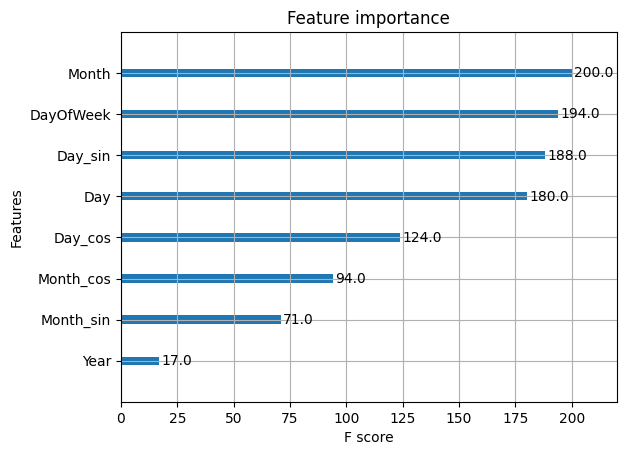

,Year,Month,Day,DayOfWeek,Quarter,TotalSales,InvoiceDate,Month_sin,Month_cos,Day_sin,Day_cos,IsHoliday,TotalSales_Lag1,TotalSales_Lag7,TotalSales_Lag30,TotalSales_Rolling7,TotalSales_Rolling30
0,2010,12,1,2,4,31033.52,2010-12-01,-2.449294e-16,1.000000,0.201299,0.979530,0,NaN,NaN,NaN,NaN,NaN
1,2010,12,2,3,4,26161.82,2010-12-02,-2.449294e-16,1.000000,0.394356,0.918958,0,31033.52,NaN,NaN,NaN,NaN
2,2010,12,3,4,4,22908.14,2010-12-03,-2.449294e-16,1.000000,0.571268,0.820763,0,26161.82,NaN,NaN,NaN,NaN
3,2010,12,5,6,4,21972.42,2010-12-05,-2.449294e-16,1.000000,0.848644,0.528964,0,22908.14,NaN,NaN,NaN,NaN
4,2010,12,6,0,4,36549.31,2010-12-06,-2.449294e-16,1.000000,0.937752,0.347305,0,21972.42,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,2011,11,3,3,4,25855.13,2011-11-03,-5.000000e-01,0.866025,0.571268,0.820763,0,25855.75,19559.42,31827.28,26132.851429,24258.597000
274,2011,11,4,4,4,29709.38,2011-11-04,-5.000000e-01,0.866025,0.724793,0.688967,0,25855.13,29979.62,22134.29,26094.245714,24511.100000
275,2011,11,6,6,4,31461.13,2011-11-06,-5.000000e-01,0.866025,0.937752,0.347305,0,29709.38,17577.38,9595.33,28077.638571,25239.960000
276,2011,11,7,0,4,22342.78,2011-11-07,-5.000000e-01,0.866025,0.988468,0.151428,0,31461.13,26850.79,24270.75,27433.637143,25175.694333


In [ ]:
# * PAR VER LA IMPORTANCIA DE LAS VARIABLES
from xgboost import plot_importance
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Leer el archivo CSV
df_to_train = pd.read_csv("../../data/dataset_training.csv")
df_to_train = add_cyclic_features(df_to_train)
df_to_train = add_holiday_feature(df_to_train)
df_to_train = add_lags(df_to_train)
df_to_train = add_rolling_means(df_to_train)

X_to_train =  df_to_train[['Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'IsHoliday', 'Month_sin', 'Month_cos', 'Day_sin', 'Day_cos']]
Y_to_train = df_to_train['TotalSales']

model =  XGBRegressor(
  n_estimators=100,     # Número de árboles
  max_depth=5,          # Profundidad máxima
  learning_rate=0.2,    # Tasa de aprendizaje
  min_child_weight=10,  # Peso mínimo necesario para crear un nodo hijo
  subsample=0.8,        # Fracción de muestras usadas para entrenar
  colsample_bytree=1,   # Fracción de características usadas por árbol
  random_state=42       # Semilla aleatoria
)
model.fit(X_to_train, Y_to_train)

plt.figure(figsize=(8, 6))
plot_importance(model)
plt.show()
df_to_train